# Oráculo: staggered-PRT

Oráculo de `docs/algorithms/staggered-prt.md`, independiente de cualquier
crate Rust (todavía no existe implementación — primer paso del método de
`docs/algorithms/roadmap.md` §"Método de estudio"). Igual que en
`dual-prf-dealiasing.md`, el criterio de aceptación es tasa de acierto del
número de pliegues, no error medio de velocidad.

**Por qué el generador de I/Q de los oráculos anteriores no sirve aquí, tal
cual.** Los oráculos previos generan la serie en el dominio espectral (FFT
de ruido conformado) porque el muestreo es uniforme. Staggered-PRT alterna
`T1, T2, T1, T2, …` *dentro* del mismo radial — el muestreo no es uniforme,
no hay una FFT ordinaria detrás. Este oráculo genera la serie directamente
en el dominio del tiempo: matriz de covarianza `C[i,j] = R(t_i - t_j)` a
partir de la misma ACF gaussiana cerrada de Doviak & Zrnić ya validada en el
oráculo del simulador de I/Q, evaluada en los tiempos de muestreo reales
(no uniformes), y un vector gaussiano complejo correlacionado por
descomposición de Cholesky de esa matriz. Es una generalización directa del
mismo modelo físico, no un mecanismo nuevo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260912)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

In [2]:
def analytic_acf(power_s, mean_v, sigma_v, wavelength_m, tau):
    """R(tau) cerrada de Doviak & Zrnic (1993) cap. 6 — la misma que valida
    el oráculo del simulador de I/Q, aquí evaluada en retardos arbitrarios,
    no sólo múltiplos de un PRT uniforme."""
    phase = np.exp(1j * 4.0 * np.pi * mean_v * tau / wavelength_m)
    decay = np.exp(-8.0 * np.pi ** 2 * sigma_v ** 2 * tau ** 2 / wavelength_m ** 2)
    return power_s * phase * decay


def staggered_times(m, t1, t2):
    dt = np.array([t1 if i % 2 == 0 else t2 for i in range(m - 1)])
    return np.concatenate([[0.0], np.cumsum(dt)])


def generate_staggered_cell(power_s, mean_v, sigma_v, wavelength_m, t1, t2, m, noise_floor, rng):
    times = staggered_times(m, t1, t2)
    tau = times[:, None] - times[None, :]
    C = analytic_acf(power_s, mean_v, sigma_v, wavelength_m, tau)
    C = (C + C.conj().T) / 2.0  # hermitizar (redondeo de punto flotante)
    L = np.linalg.cholesky(C + 1e-9 * power_s * np.eye(m))
    z = (rng.normal(0.0, 1.0, m) + 1j * rng.normal(0.0, 1.0, m)) / np.sqrt(2.0)
    x = L @ z
    if noise_floor > 0.0:
        x = x + (rng.normal(0.0, np.sqrt(noise_floor / 2.0), m)
                  + 1j * rng.normal(0.0, np.sqrt(noise_floor / 2.0), m))
    return x


checks = []

## Dos autocovarianzas, un desdoblado

`R(T1)` de los pares separados por `T1`, `R(T2)` de los pares separados por
`T2` — de la **misma** serie, sin brecha temporal entre ambas medidas (la
ventaja que la página reclama frente al dual-PRF). El desdoblado reutiliza
exactamente el mismo mecanismo de reconciliación por teorema chino del resto
que `dual-prf-dealiasing.md` — la razón `T1:T2 = 2:3` da `2·v_a1 = 3·v_a2`,
la misma estructura matemática, sólo cambia de dónde salen `v1` y `v2`.

In [3]:
WAVELENGTH_M = 0.10
T1, T2 = 0.8e-3, 1.2e-3  # razon 2:3
V_A1 = WAVELENGTH_M / (4.0 * T1)
V_A2 = WAVELENGTH_M / (4.0 * T2)
V_EXT = 2.0 * V_A1
print(f"v_a1={V_A1:.3f} m/s  v_a2={V_A2:.3f} m/s  v_ext=2*v_a1={V_EXT:.3f} m/s (= 3*v_a2={3*V_A2:.3f})")


def fold(v, v_a):
    return ((v + v_a) % (2.0 * v_a)) - v_a


def dealias(v1_meas, v2_meas, v_a1=V_A1, v_a2=V_A2, v_ext=V_EXT):
    n_range = int(np.ceil(v_ext / (2.0 * v_a1))) + 1
    best_err, best_v = np.inf, None
    for n1 in range(-n_range, n_range + 1):
        v_cand = v1_meas + 2.0 * v_a1 * n1
        if abs(v_cand) > v_ext + v_a1:
            continue
        err = abs(fold(v_cand, v_a2) - v2_meas)
        err = min(err, 2.0 * v_a2 - err)
        if err < best_err:
            best_err, best_v = err, v_cand
    return best_v, best_err


M_PULSES = 32
NOISE_FLOOR = 0.05


def dealias_trial(v_true, sigma_v, snr_db, m=M_PULSES, rng=rng):
    power_s = NOISE_FLOOR * 10.0 ** (snr_db / 10.0)
    x = generate_staggered_cell(power_s, v_true, sigma_v, WAVELENGTH_M, T1, T2, m, NOISE_FLOOR, rng)
    r1 = np.mean(x[0:-1:2] * np.conj(x[1::2]))
    r2 = np.mean(x[1:-1:2] * np.conj(x[2::2]))
    v1 = -WAVELENGTH_M / (4.0 * np.pi * T1) * np.angle(r1)
    v2 = -WAVELENGTH_M / (4.0 * np.pi * T2) * np.angle(r2)
    v_hat, _ = dealias(v1, v2)
    return v_hat


def is_hit(v_hat, v_true):
    return abs(v_hat - v_true) < V_A2

v_a1=31.250 m/s  v_a2=20.833 m/s  v_ext=2*v_a1=62.500 m/s (= 3*v_a2=62.500)


## Misma degeneración estructural que el dual-PRF cerca del borde

Igual que en `dual-prf-dealiasing.md` (la misma razón 2:3, la misma
aritmética de reconciliación), hay velocidades cerca del extremo de
`v_ext` donde dos números de pliegue reconcilian casi igual de bien —no es
un defecto de esta implementación en particular, es la razón 2:3 misma. Se
declara y se excluye de la malla principal, igual que allí.

{np.float64(-56.2): np.float64(0.53), np.float64(-42.2): np.float64(0.61), np.float64(-28.1): np.float64(1.0), np.float64(-14.1): np.float64(1.0), np.float64(0.0): np.float64(1.0), np.float64(14.1): np.float64(1.0), np.float64(28.1): np.float64(1.0), np.float64(42.2): np.float64(0.48), np.float64(56.2): np.float64(0.5)}


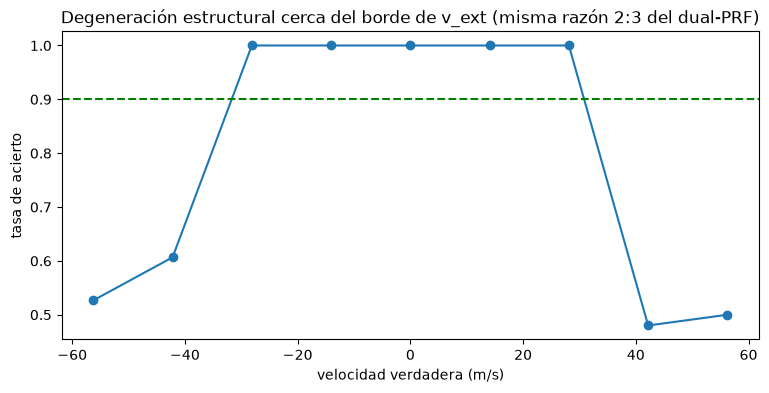

In [4]:
v_true_grid = np.linspace(-0.9 * V_EXT, 0.9 * V_EXT, 9)
hit_by_v = [sum(is_hit(dealias_trial(v, 1.5, 20.0), v) for _ in range(150)) / 150 for v in v_true_grid]
print(dict(zip(np.round(v_true_grid, 1), np.round(hit_by_v, 2))))

fig, ax = plt.subplots()
ax.plot(v_true_grid, hit_by_v, marker="o")
ax.axhline(0.9, color="green", linestyle="--")
ax.set_xlabel("velocidad verdadera (m/s)"); ax.set_ylabel("tasa de acierto")
ax.set_title("Degeneración estructural cerca del borde de v_ext (misma razón 2:3 del dual-PRF)")
plt.show()

## Prueba 1 — malla (SNR, σv) en la zona segura

La página pide medir la tasa de acierto en función de SNR **y** ancho
espectral, exigiendo degradación suave — a diferencia del dual-PRF, aquí no
hay cizalladura que medir: las dos autocovarianzas vienen de la misma
realización, sin brecha temporal, así que esa fuente de error
estructuralmente no existe en este generador (es la ventaja de la página,
no una simplificación de este oráculo).

In [5]:
V_SAFE = 0.4 * V_EXT
SNR_DB_GRID = [-5.0, 0.0, 5.0, 10.0, 15.0, 20.0]
SIGMA_V_GRID = [0.5, 1.5, 3.0, 6.0]
N_TRIALS = 200

hit_rates = {}
print(f"{'SNR':>5} {'sv':>4} {'hit_rate':>9}")
for snr_db in SNR_DB_GRID:
    for sigma_v in SIGMA_V_GRID:
        hits = sum(is_hit(dealias_trial(V_SAFE, sigma_v, snr_db), V_SAFE) for _ in range(N_TRIALS))
        rate = hits / N_TRIALS
        hit_rates[(snr_db, sigma_v)] = rate
        print(f"{snr_db:5.1f} {sigma_v:4.1f} {rate:9.2f}")

# degradacion suave: la tasa a SNR baja no debe ser mayor que a SNR alta, para cada sigma_v
smooth_ok = True
for sigma_v in SIGMA_V_GRID:
    series = [hit_rates[(snr, sigma_v)] for snr in SNR_DB_GRID]
    if any(series[i] > series[i + 1] + 0.05 for i in range(len(series) - 1)):
        smooth_ok = False

high_snr_ok = all(hit_rates[(20.0, sv)] >= 0.95 for sv in SIGMA_V_GRID)

checks.append(("a SNR alta (20 dB) la tasa de acierto es >= 95% en todo el barrido de σv", high_snr_ok))
checks.append(("la tasa de acierto no cae al aumentar la SNR, en ningún σv (degradación suave, sin saltos)", smooth_ok))
checks.append(("a SNR muy baja (-5 dB) la tasa de acierto se degrada medible y claramente (< 90%)",
               all(hit_rates[(-5.0, sv)] < 0.90 for sv in SIGMA_V_GRID)))

  SNR   sv  hit_rate
 -5.0  0.5      0.66
 -5.0  1.5      0.64
 -5.0  3.0      0.62
 -5.0  6.0      0.62


  0.0  0.5      0.89
  0.0  1.5      0.93
  0.0  3.0      0.91
  0.0  6.0      0.91


  5.0  0.5      0.95
  5.0  1.5      1.00
  5.0  3.0      1.00
  5.0  6.0      1.00
 10.0  0.5      0.99
 10.0  1.5      1.00


 10.0  3.0      1.00
 10.0  6.0      1.00
 15.0  0.5      1.00
 15.0  1.5      1.00
 15.0  3.0      1.00
 15.0  6.0      1.00
 20.0  0.5      1.00


 20.0  1.5      1.00
 20.0  3.0      1.00
 20.0  6.0      1.00


## Fuera de alcance, declarado

- **Filtrado de clutter en muestreo escalonado** (Sachidananda & Zrnić 2000:
  descomponer en las dos subsecuencias uniformes, filtrar, reconstruir). La
  propia página lo marca como "el trabajo más pesado de esta técnica" y
  autoriza explícitamente ofrecer staggered-PRT sin filtro de clutter en
  Stage 1, declarándolo en las capacidades — este oráculo se ciñe a esa
  misma frontera de alcance, no la amplía por su cuenta.
- **Interacción con polarimetría alternante**: regla de rechazo de
  configuración (`dealias_mask`/`capability_flags`), no una cantidad con
  verdad-terreno numérica propia — igual que en `dual-prf-dealiasing.md`.

In [6]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo de staggered-PRT no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")

[OK] a SNR alta (20 dB) la tasa de acierto es >= 95% en todo el barrido de σv
[OK] la tasa de acierto no cae al aumentar la SNR, en ningún σv (degradación suave, sin saltos)
[OK] a SNR muy baja (-5 dB) la tasa de acierto se degrada medible y claramente (< 90%)

Todas las comprobaciones dentro de tolerancia.
